<h1> Experiment anti HOM probability against bandwith </h1>

In [41]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_bandwith import run_coincidence_vs_bandwith

<h2> Execute the experiment </h2>

In [25]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Order of the bare parameters
n = 2

#Different photon frequencies
omega_q_tab = [9*pi, 7*pi, 5*pi]

#Choose photon frequency
index_omega_q = 1
omega_q = omega_q_tab[index_omega_q-1]
delta_q = 0.05*pi


#Prepare a tab of IR and UV cutoffs for each experiment
nb_pts_bandwith = 15
ir_tab_list = []
uv_tab_list = []
#Experiments 1,2,3 : IR cutoff fixed, UV increased
ir_values = [0*pi, pi, 2*pi]
for i in range(3):
    ir_tab_list.append(ir_values[i] * np.ones(nb_pts_bandwith))
    uv_tab_list.append(np.linspace(ir_values[i] + 2*pi, 30*pi, nb_pts_bandwith))
#Experiments 4,5,6 : central frequency fixed, bandwith increased
central_freqs = [10*pi, 9*pi, 8*pi]
for i in range(3):
    bandwith_tab = np.linspace(pi, central_freqs[i], nb_pts_bandwith)
    ir_tab_list.append(central_freqs[i] - bandwith_tab)
    uv_tab_list.append(central_freqs[i] + bandwith_tab)


#Parameters of the simulation
L = 50

param_cavity_physical = {'omega_A': omega_A, 'Gamma': Gamma, 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.01}

param_photons = {'omega_p': [omega_q, omega_q], 
                 'delta_k': [delta_q, delta_q],
                 'x_0': [-L/4, -L/4]}

Run the experiment

In [26]:
for i in range(len(ir_tab_list)):
        index_experiment = i+1
        print("Running frequency window ", index_experiment, " out of ", len(ir_tab_list))

        ir_tab = ir_tab_list[i]
        uv_tab = uv_tab_list[i]
                
        _, _, coincidence_tab = run_coincidence_vs_bandwith(param_photons, param_cavity_physical, param_time_evol, ir_tab, uv_tab, 
                                                            index_omega_q, index_experiment, n=n)
            
        print("------------- \n")

Running frequency window  1  out of  6


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [23:32<00:00, 94.19s/it] 


------------- 

Running frequency window  2  out of  6


  0%|          | 0/15 [00:00<?, ?it/s]

...

------------- 

Running frequency window  5  out of  6


100%|██████████| 15/15 [09:13<00:00, 36.91s/it]


------------- 

Running frequency window  6  out of  6


100%|██████████| 15/15 [09:05<00:00, 36.39s/it]

------------- 



<h2> Convergence per frequency </h2>

Recover the data

In [45]:
n=2
index_omega_q = 1
R_theory_physical = 1 / (1 + ((omega_q_tab[index_omega_q-1] - omega_A)/ (Gamma/2))**2)
theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

#non monochromatic correction
if np.abs(theoretical_val) < 1e-1:
    non_monochr_ratio = Gamma / (2*delta_q)
    theoretical_val += 1/(np.sqrt(pi) * non_monochr_ratio)

coincidence_to_plot = []
bandwith_to_plot = []

for i in range(len(ir_tab_list)):
    index_experiment = i+1
    if n > 1:
        data_file = f"../results/csv_files/coincidence_vs_bandwith/coincidence_vs_bandwith_{index_omega_q}_{index_experiment}_n{n}.csv"
    else:
        data_file = f"../results/csv_files/coincidence_vs_bandwith/coincidence_vs_bandwith_{index_omega_q}_{index_experiment}.csv"
    df = pd.read_csv(data_file)
    coincidence_to_plot.append(df['coincidence_tab'].to_numpy())
    ir_tab = df['ir_tab'].to_numpy()
    uv_tab = df['uv_tab'].to_numpy()

    bandwith_to_plot.append(uv_tab - ir_tab)

Create the figure

Relative error for window 0: 0.573 %
Relative error for window 1: 0.105 %
Relative error for window 2: 1.032 %


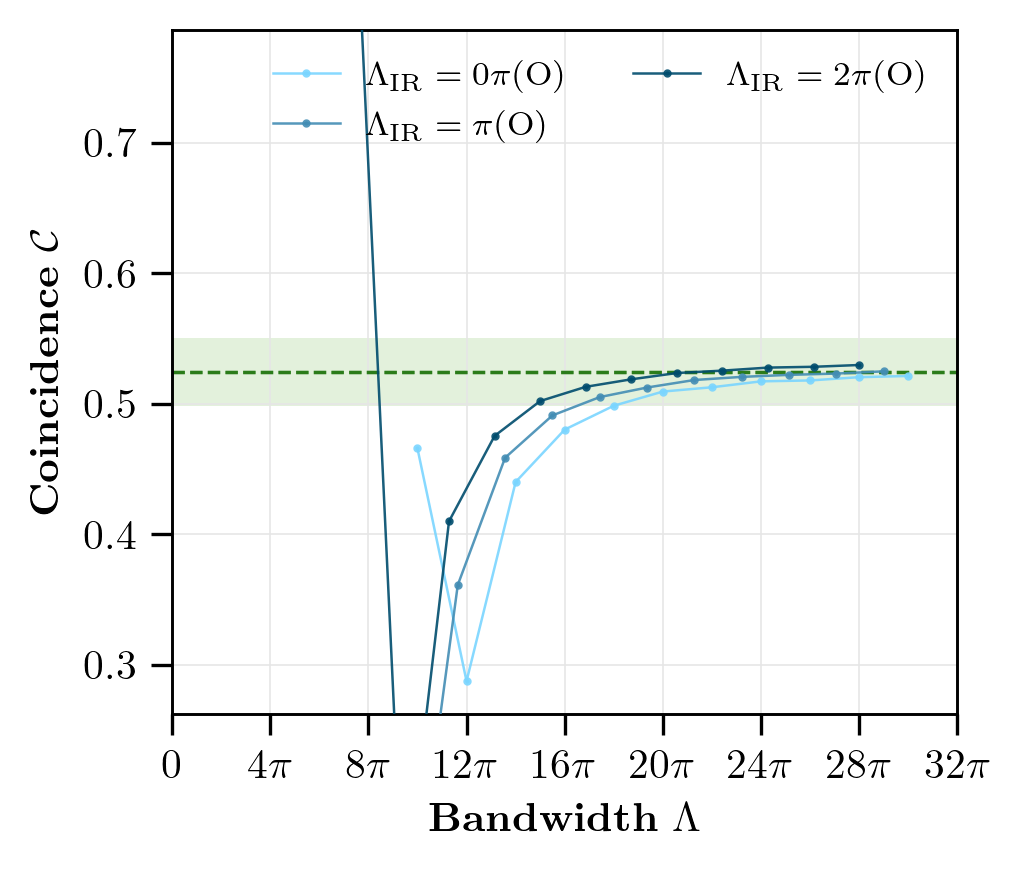

In [46]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)

# Palette sobre + markers distincts

colors  = ["#7ad5ff", "#438db4", "#004c6d", 
           "#ffb69d", "#b6644b", "#6d1200"]
labels  = [r'$\Lambda_{\rm IR} = 0\pi$', r'$\Lambda_{\rm IR} = \pi$', r'$\Lambda_{\rm IR} = 2\pi$', 
           r'$\omega_{\rm ref} = 10\pi$', r'$\omega_{\rm ref} = 9\pi$', r'$\omega_{\rm ref} = 8\pi$']

lbda_conv = np.zeros(len(ir_tab_list))

# Scatter plots
#for i in range(len(lbda_conv)):
for i in [0,1,2]:
    relative_error = np.abs(coincidence_to_plot[i][-1] - theoretical_val) / theoretical_val
    print(f"Relative error for window {i}: {relative_error*100:.3f} %")

    #Index where the curve enters the 5% confidence region
    if (relative_error < 0.05):
        lbda_conv[i] = bandwith_to_plot[i][np.where((coincidence_to_plot[i] < 1.05*theoretical_val) & 
                                                    (coincidence_to_plot[i] > 0.95*theoretical_val))[0][0]]
        labels[i] += '(O)'
    else:
        lbda_conv[i] = np.inf
        labels[i] += '(X)'

    ax.plot(
        bandwith_to_plot[i],
        coincidence_to_plot[i],
        marker="o",
        label = labels[i],
        color = colors[i],
        markersize=1,
        linewidth=0.6,
        alpha=0.9,
        zorder=3
    )
    #5% confidence region
    ax.hlines(theoretical_val, 0, 100*pi, color='#126d00',alpha=0.5, linewidth=0.8, linestyle='--')
    ax.fill_between(np.linspace(0, 100*pi, 100),
                    0.95*theoretical_val,
                    1.05*theoretical_val,color='#aad997',alpha=0.12,linewidth=0, zorder=1)

#legend outside the plot
ax.legend(
    prop={'size': 8},
    frameon=True,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

ax.set_xlim([0, 32*pi])
# Espacement des ticks (ici tous les 2π)
ax.xaxis.set_major_locator(MultipleLocator(4*np.pi))

# Formatage automatique en unités de π
def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    else:
        return rf"${int(round(n))}\pi$"

ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

ax.set_ylim([0.5*theoretical_val, 1.5*theoretical_val])

# Labels
ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=13)
ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=13)

#grid
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Legend (sobre, sans cadre)
ax.legend(prop={'size': 8}, ncols=2, frameon=False, loc="best")

# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
#plt.savefig(f'../results/fig/coincidence_vs_bandwith_omegaq_{index_omega_q}.pdf', bbox_inches="tight")
plt.show()

<h2> Convergence per truncation scheme </h2>

Recover the data

In [ ]:
index_experiment = 6

coincidence_to_plot = []
bandwith_to_plot = []
theoretical_val_list = []
relative_error_list = []

for j in range(len(omega_q_tab)):

    index_omega_q = j+1

    R_theory_physical = 1 / (1 + ((omega_q_tab[index_omega_q-1] - omega_A)/ (Gamma/2))**2)
    theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)

    #non monochromatic correction
    if np.abs(theoretical_val) < 1e-1:
        non_monochr_ratio = Gamma / (2*delta_q)
        theoretical_val += 1/(np.sqrt(pi) * non_monochr_ratio)

    theoretical_val_list.append(theoretical_val)


    data_file = f"../results/csv_files/concidence_vs_bandwith/coincidence_vs_bandwith_{index_omega_q}_{index_experiment}.csv"

    df = pd.read_csv(data_file)
    coincidence_to_plot.append(df['coincidence_tab'].to_numpy())
    ir_tab = df['ir_tab'].to_numpy()
    uv_tab = df['uv_tab'].to_numpy()

    bandwith_to_plot.append(uv_tab - ir_tab)

    relative_error_list.append(np.abs(coincidence_to_plot[-1][-1] - theoretical_val_list[-1])/theoretical_val_list[-1])

Create the figure

Relative error for omega_q = 9.0 pi: 3.017 %
Relative error for omega_q = 7.0 pi: 2.358 %
Relative error for omega_q = 5.0 pi: 1.420 %


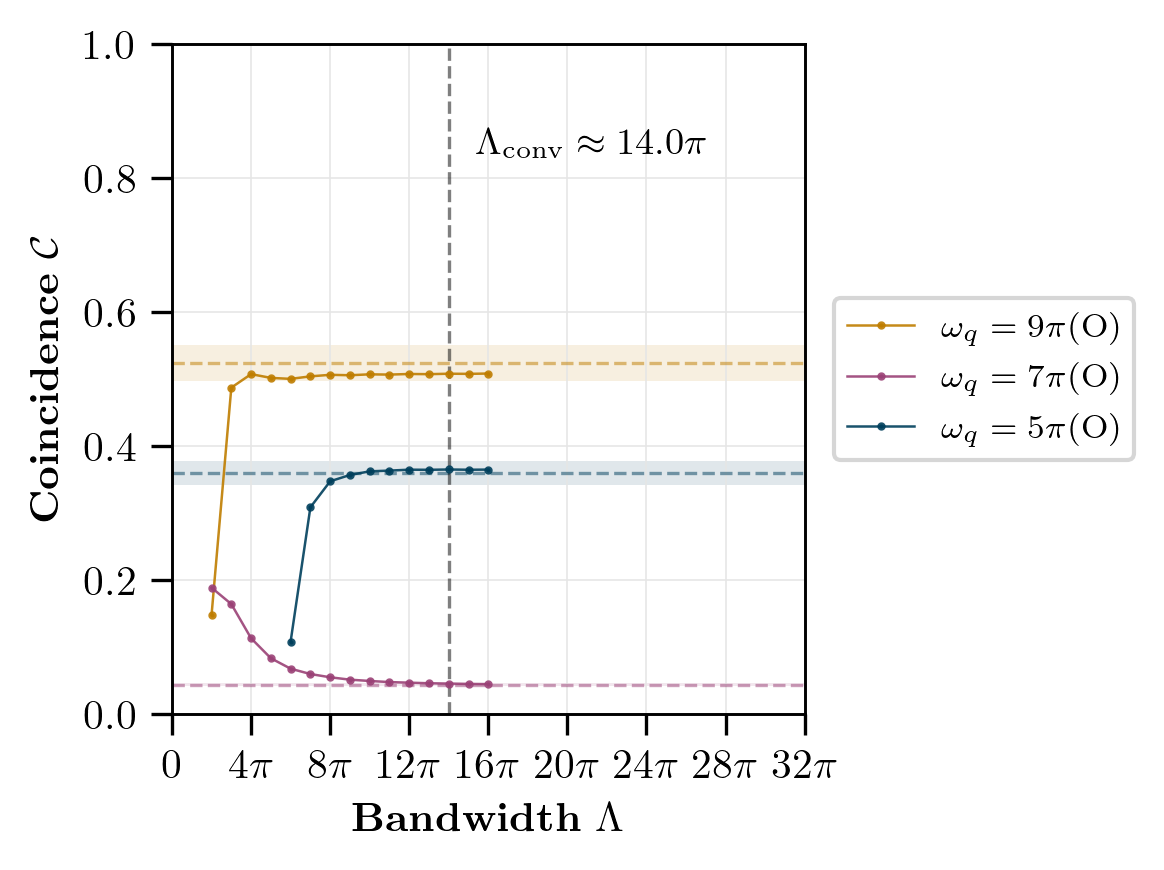

In [23]:
# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Palette sobre + markers distincts
colors  = ["#bf7d00", "#9a4176", "#003f5c"]
labels  = [r'$\omega_q = 9\pi$', r'$\omega_q = 7\pi$', r'$\omega_q = 5\pi$']
lbda_conv = np.zeros(len(omega_q_tab))

# Scatter plots
for j in range(len(omega_q_tab)):
    print(f"Relative error for omega_q = {omega_q_tab[j]/pi:.1f} pi: {relative_error_list[j]*100:.3f} %")
    #Index where the curve enters the 5% confidence region
    if (coincidence_to_plot[j][-1] > 0.95*theoretical_val_list[j] and coincidence_to_plot[j][-1] < 1.05 * theoretical_val_list[j]):
        lbda_conv[j] = bandwith_to_plot[j][np.where((coincidence_to_plot[j] < 1.05*theoretical_val_list[j]) & 
                                                    (coincidence_to_plot[j] > 0.95*theoretical_val_list[j]))[0][0]]
        labels[j] += '(O)'
    else:
        lbda_conv[j] = np.inf
        labels[j] += '(X)'

    ax.plot(
        bandwith_to_plot[j],
        coincidence_to_plot[j],
        marker="o",
        color=colors[j],
        label = labels[j],
        markersize=1,
        linewidth=0.6,
        alpha=0.9,
        zorder=3
    )
    #5% confidence region
    ax.hlines(theoretical_val_list[j], 0, 100*pi,color=colors[j], alpha=0.5, linewidth=0.8, linestyle='--')
    ax.fill_between(np.linspace(0, 100*pi, 100),
                    0.95*theoretical_val_list[j],
                    1.05*theoretical_val_list[j],color=colors[j],alpha=0.12,linewidth=0, zorder=1)

#Indicate largest lbda_conv if non nan (ie all curves enter the confidence region)
max_lbda_conv = np.max(lbda_conv)
if not np.isinf(max_lbda_conv):
    #Display numerical lbda_conv in pi units
    ax.text(
        1.1 * max_lbda_conv/(32*pi),
        0.85,
        r'$\Lambda_{\mathrm{conv}} \approx ' + f"{max_lbda_conv/pi:.1f}" + r'\pi$',
        color='black',
        fontsize=9,
        va='center',
        ha='left',
        transform=ax.get_yaxis_transform()
    )
    ax.vlines(max_lbda_conv, 0, 1, color='black', alpha=0.5, linestyle='--', linewidth=0.8)

#legend outside the plot
ax.legend(
    prop={'size': 8},
    frameon=True,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)


ax.set_xlim([0, 32*pi])
# Espacement des ticks (ici tous les 2π)
ax.xaxis.set_major_locator(MultipleLocator(4*np.pi))

# Formatage automatique en unités de π
def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return "0"
    elif np.isclose(n, 1):
        return r"$\pi$"
    else:
        return rf"${int(round(n))}\pi$"

ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

ax.set_ylim([0,1])

# Labels
ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=13)
ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=13)

#grid
ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Legend (sobre, sans cadre)
#ax.legend(prop={'size': 8}, frameon=False, loc="best")

# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
plt.savefig(f'../results/fig/coincidence_vs_bandwith_xp_{index_experiment}.pdf', bbox_inches="tight")
plt.show()